# Interactive quickstart

This notebook is the executed, cell-by-cell twin of the
[Quickstart](../quickstart.html): the class-first path from an empty kernel
to a finished, reproducible run, with every output actually produced by
running the cell above it (this is a real `.ipynb` — commit-time output,
not a transcript). Run it yourself, or read the outputs below as they were
captured when this notebook was last executed.


## The problem

`sezgi.bbob(fid, dim, instance)` returns a native `Problem` handle for one
of the 24 noiseless BBOB/COCO functions. `fid=1` is the Sphere function
(`f(x) = sum(x_i^2)`), a smooth unimodal baseline — no subclassing needed,
since the objective and its known optimum already live compiled into the
Rust core.


In [1]:
import sezgi

problem = sezgi.bbob(1, 5, 1)  # BBOB f1 (Sphere), dim=5, instance=1
print(type(problem))


<class 'sezgi._sezgi.Problem'>


## The algorithm

Every built-in algorithm in `sezgi` is a class in `sezgi.builtins`,
imported directly off the top-level `sezgi` namespace. `GeneticAlgorithm`
is one of the ~30 preset-backed wrapper classes: its constructor takes
algorithm hyperparameters (`pop_size` here), and its `.run()` method takes
the per-run arguments (`problem`, `budget`, `seed`).


In [2]:
algo = sezgi.GeneticAlgorithm(pop_size=20)
result = algo.run(problem, budget=1000, seed=1)
print(result)


SolveResult(algo='geneticalgorithm', seed=1, budget=1000, evals_used=1000, best_x=[2.5649048665803207, 1.8505248442574043, 3.322513036962495, 2.5426460403641102, -3.7109149583700916], best_f=-125.94250099117657, f_opt=-125.9497035670884, gap=0.007202575911833264)


## Every field of `SolveResult`

`SolveResult` — the return type of every scalar wrapper class's `.run()`
(`NSGA2` is the one exception; it returns its own multi-objective result
dictionary instead) — carries eight fields. Let's look at each one on its
own rather than at the repr printed above.


In [3]:
print(f"algo        = {result.algo!r}")
print(f"seed        = {result.seed}")
print(f"budget      = {result.budget}")
print(f"evals_used  = {result.evals_used}")


algo        = 'geneticalgorithm'
seed        = 1
budget      = 1000
evals_used  = 1000


`algo` is the wrapper class's own name, lowercased (`"geneticalgorithm"`
here), not the underlying preset it dispatched to. It identifies which
wrapper class produced the result; for `GeneticAlgorithm`, the
representation actually engaged (`"real"` for this Float-typed problem) is
exposed separately as `algo.dispatched_representation` on the
`GeneticAlgorithm` instance itself — not a field on `SolveResult`.
`seed`, `budget`, and `evals_used` are the run's own bookkeeping;
`evals_used` equals `budget` unless the algorithm terminates early (no
built-in does today).


In [4]:
print(f"best_x[:3]  = {result.best_x[:3]}")
print(f"best_f      = {result.best_f:.6g}")
print(f"f_opt       = {result.f_opt:.6g}")
print(f"gap         = {result.gap:.6g}")


best_x[:3]  = [2.5649048665803207, 1.8505248442574043, 3.322513036962495]
best_f      = -125.943
f_opt       = -125.95
gap         = 0.00720258


`best_x` is the best point this run actually *evaluated* (a plain
`list[float]`, dim=5, for this Float-typed problem — not guaranteed to lie
within the problem's declared bounds for every algorithm, see
[Solve / compat internals](../api/compat.html)). `best_f` is the objective
value there. `f_opt` is this problem's known optimum — BBOB functions ship
an exact one, so it is a real float, not `None`. `gap` is
`best_f - f_opt`, the standard way to report one run's quality without any
cross-algorithm ranking claim attached (see
[Comparing algorithms fairly](../learn/05-comparing-algorithms-fairly.html)).


## Determinism: the same seed twice

`seed` fixes every random draw a run makes, so the SAME
`(problem, budget, seed)` triple always reproduces the SAME `result`,
bit-for-bit, in this build (see
[Determinism and the RNG model](../concepts/rng-and-determinism.html)). This
cell re-runs the exact call above and asserts the two results agree on
every field that matters — not just eyeballing two printouts.


In [5]:
result_again = sezgi.GeneticAlgorithm(pop_size=20).run(problem, budget=1000, seed=1)

assert result_again.best_x == result.best_x
assert result_again.best_f == result.best_f
assert result_again.evals_used == result.evals_used

print("same seed twice: best_x, best_f, evals_used all bit-identical -- OK")


same seed twice: best_x, best_f, evals_used all bit-identical -- OK


## A look at convergence

The cell below re-runs the exact same `(problem, algorithm, seed)` at six
increasing budgets, each budget its own independent `.run()` call — not a
single logged run truncated after the fact (`.run()` is only ever called
once here; nothing is replayed). Every budget below is chosen as an exact
multiple of `pop_size=20`, so each run completes a whole number of
generations with none left partial.

This matters because `GeneticAlgorithm`'s generator never reads the total
budget while it runs (unlike a budget-adaptive preset such as `lshade`),
so an independent run at a smaller budget lands on the same point a
longer run with the same seed would have reached *whenever the two runs
complete the same number of generations* — the engine only ever evaluates
whole generation batches, so a budget that stops mid-generation (not the
case for any budget chosen below) would be the one situation where that
prefix equality breaks. See
[Reading convergence curves](../learn/06-reading-convergence-curves.html)
for the general statement and its one documented exception.


budget=100   evals_used=100   gap=6.65846
budget=200   evals_used=200   gap=3.96005
budget=400   evals_used=400   gap=0.208582
budget=600   evals_used=600   gap=0.0216981
budget=900   evals_used=900   gap=0.00740714
budget=1200  evals_used=1200  gap=0.00354253


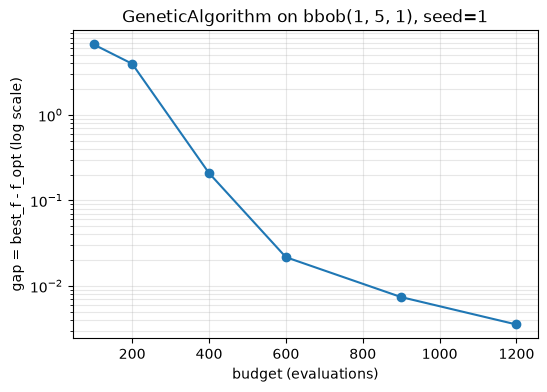

In [6]:
import matplotlib.pyplot as plt

budgets = [100, 200, 400, 600, 900, 1200]  # all multiples of pop_size=20
gaps = []
for b in budgets:
    r = sezgi.GeneticAlgorithm(pop_size=20).run(problem, budget=b, seed=1)
    gaps.append(r.gap)
    print(f"budget={b:<5} evals_used={r.evals_used:<5} gap={r.gap:.6g}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(budgets, gaps, marker="o")
ax.set_yscale("log")
ax.set_xlabel("budget (evaluations)")
ax.set_ylabel("gap = best_f - f_opt (log scale)")
ax.set_title("GeneticAlgorithm on bbob(1, 5, 1), seed=1")
ax.grid(True, which="both", alpha=0.3)
plt.show()


## Next

- [Quickstart](../quickstart.html) — the same walk-through as a static,
  build-time-executed page.
- [Tutorial 1: Your first optimization](../tutorials/01-first-optimization.html)
  — the same ground, one field at a time, in prose.
- [Writing your own algorithm](02-your-own-algorithm.html) — the next
  notebook: author both a `Problem` and an `Algorithm` yourself.
